# Bellabeat wellness case study — data preparation and EDA

**Unit of analysis:** one row per person and day for activity and sleep; one row per person and hour for usage patterns. Run cells in order. Edit `DATA_DIR` in the next cell to the folder containing the source CSVs. Filenames with or without `(1)` work.

Missing sleep means no recorded sleep total. It is not zero sleep. The minute sleep codes do not reliably reproduce the daily sleep totals and therefore are not used to fill them.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

DATA_DIR = Path(r'C:\Users\ankan\Desktop\LabmentixPR\Strava Fitness')
OUTPUT_DIR = DATA_DIR / 'Cleaned_Data'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def source_path(stem):
    for filename in (f'{stem}(2).csv', f'{stem}.csv', f'{stem}(1).csv'):
        candidate = DATA_DIR / filename
        if candidate.is_file():
            return candidate
    raise FileNotFoundError(f'Missing {stem} CSV in {DATA_DIR}')


def load(stem):
    frame = pd.read_csv(source_path(stem))
    frame.columns = frame.columns.str.strip()
    return frame.drop_duplicates().copy()


def parse_date(frame, original, fmt):
    frame['Date'] = pd.to_datetime(frame[original], format=fmt, errors='coerce').dt.normalize()
    if frame['Date'].isna().any():
        raise ValueError(f'Invalid {original} values: {frame["Date"].isna().sum()}')
    return frame


def unique_keys(frame, columns, name):
    count = int(frame.duplicated(columns).sum())
    if count:
        raise ValueError(f'{name}: {count} repeated keys {columns}; review before joining')


for stem in ('dailyActivity_merged', 'hourlySteps_merged', 'hourlyCalories_merged',
             'sleepDay_merged', 'weightLogInfo_merged', 'heartrate_seconds_merged'):
    def source_path(stem):
        for filename in (f'{stem}(2).csv', f'{stem}.csv', f'{stem}(1).csv'):
            candidate = DATA_DIR / filename
            if candidate.is_file():
                return candidate

        normalized_stem = ''.join(c for c in stem.casefold() if c.isalnum())
        matches = [
            path for path in DATA_DIR.rglob('*.csv')
            if ''.join(c for c in path.stem.casefold() if c.isalnum()).startswith(normalized_stem)]
        if matches:
            return matches[0]

        available = [path.name for path in DATA_DIR.rglob('*.csv')]
        raise FileNotFoundError(
            f'Missing {stem} CSV in {DATA_DIR}. CSV files found: {available}')

## 1. Daily activity and sleep
The daily activity file contains steps, calories, distance and intensity minutes. Remove the three identical sleep duplicates, then join sleep on Id and calendar date. Preserve the original activity and sleep columns.

In [ ]:
activity = parse_date(load('dailyActivity_merged'), 'ActivityDate', '%m/%d/%Y')
unique_keys(activity, ['Id', 'Date'], 'dailyActivity')

sleep = parse_date(load('sleepDay_merged'), 'SleepDay', '%m/%d/%Y %I:%M:%S %p')
unique_keys(sleep, ['Id', 'Date'], 'sleepDay')

daily = activity.merge(sleep, on=['Id', 'Date'], how='left', validate='one_to_one')
assert len(daily) == len(activity)
print('Daily rows:', len(daily), '| Recorded sleep days:', daily['TotalMinutesAsleep'].notna().sum())

Daily rows: 940 | Recorded sleep days: 410


In [16]:
daily['SleepDataStatus'] = np.where(daily['TotalMinutesAsleep'].notna(), 'Available', 'Unavailable')
daily['DayName'] = daily['Date'].dt.day_name()
daily['DayNumber'] = daily['Date'].dt.dayofweek + 1
daily['DayType'] = np.where(daily['DayNumber'] >= 6, 'Weekend', 'Weekday')

daily['TotalActiveMinutes'] = (daily['VeryActiveMinutes'] +
                               daily['FairlyActiveMinutes'] +
                               daily['LightlyActiveMinutes'])
daily['ActiveHours'] = (daily['TotalActiveMinutes'] / 60).round(2)
daily['SleepHours'] = (daily['TotalMinutesAsleep'] / 60).round(2)
daily['SleepEfficiency'] = (100 * daily['TotalMinutesAsleep'] /
                            daily['TotalTimeInBed'].replace(0, np.nan)).round(2)
daily['WearTimeMinutes'] = daily['TotalActiveMinutes'] + daily['SedentaryMinutes']
daily['WearTimeCheck'] = np.select(
    [daily['WearTimeMinutes'] > 1440, daily['WearTimeMinutes'] < 600],
    ['Above 24 hours - review', 'Under 10 hours - review'], default='Within range')
daily['SedentaryPercentage'] = (100 * daily['SedentaryMinutes'] /
                                daily['WearTimeMinutes'].replace(0, np.nan)).round(2)
daily['ActivePercentage'] = (100 * daily['TotalActiveMinutes'] /
                             daily['WearTimeMinutes'].replace(0, np.nan)).round(2)
daily['StepsPerActiveMinute'] = (daily['TotalSteps'] /
                                 daily['TotalActiveMinutes'].replace(0, np.nan)).round(2)
# These are chosen analysis thresholds, not thresholds supplied by the Fitbit data.
daily['StepsGoalMet'] = np.where(daily['TotalSteps'] >= 10000, 'Yes', 'No')
daily['SleepGoalMet'] = np.select(
    [daily['TotalMinutesAsleep'].isna(), daily['TotalMinutesAsleep'] >= 420],
    ['Unknown', 'Yes'], default='No')
daily['ActivityLevel'] = pd.cut(daily['TotalSteps'],
    bins=[-1, 4999, 7499, 9999, np.inf],
    labels=['Under 5k', '5k-7.5k', '7.5k-10k', '10k+'])
unique_keys(daily, ['Id', 'Date'], 'daily_wellness')

## 2. Hourly steps and calories
Join the two supplied hourly files on Id and ActivityHour. Keep the hourly table separate from the daily table, then aggregate it to Id and date for a safe daily join.

In [ ]:
fmt = '%m/%d/%Y %I:%M:%S %p'
hour_steps = load('hourlySteps_merged')
hour_calories = load('hourlyCalories_merged').rename(columns={'Calories': 'HourlyCalories'})

for name, table in [('steps', hour_steps), ('calories', hour_calories)]:
    table['ActivityHour'] = pd.to_datetime(table['ActivityHour'], format=fmt, errors='coerce')
    if table['ActivityHour'].isna().any():
        raise ValueError(f'Invalid hourly timestamp in {name}')
    unique_keys(table, ['Id', 'ActivityHour'], name)

hourly = hour_steps.merge(hour_calories, on=['Id', 'ActivityHour'], how='outer',
                          validate='one_to_one', indicator='CalorieMatch')
hourly['Date'] = hourly['ActivityHour'].dt.normalize()
hourly['Hour'] = hourly['ActivityHour'].dt.hour
hourly['DayName'] = hourly['ActivityHour'].dt.day_name()
hourly['DayNumber'] = hourly['ActivityHour'].dt.dayofweek + 1
hourly['DayType'] = np.where(hourly['DayNumber'] >= 6, 'Weekend', 'Weekday')
hourly['TimePeriod'] = pd.cut(hourly['Hour'], bins=[-1, 4, 11, 16, 20, 23],
    labels=['Night', 'Morning', 'Afternoon', 'Evening', 'Late night'])
unique_keys(hourly, ['Id','ActivityHour'], 'hourly_activity')

hourly_daily = hourly.groupby(['Id', 'Date'], as_index=False).agg(
    HourlyRecords=('ActivityHour', 'size'),
    HourlyStepsTotal=('StepTotal', 'sum'),
    HourlyCaloriesTotal=('HourlyCalories', 'sum'),
    HoursWithSteps=('StepTotal', lambda x: int(x.gt(0).sum())))
print('Hourly rows:', len(hourly), '| Matches:', hourly['CalorieMatch'].value_counts().to_dict())

Hourly rows: 22099 | Matches: {'both': 22099, 'left_only': 0, 'right_only': 0}


## 3. Weight measurements
Weight logs are sparse. Match a log to the calendar date of its timestamp; keep the original timestamp as WeightLogTime. Do not fill missing weight values.

In [ ]:
weight = load('weightLogInfo_merged')
weight['Date'] = pd.to_datetime(weight['Date'], format=fmt, errors='coerce')
if weight['Date'].isna().any():
    raise ValueError('Invalid weight timestamps')
weight = weight.rename(columns={'Date': 'WeightLogTime'})
weight['Date'] = weight['WeightLogTime'].dt.normalize()
unique_keys(weight, ['Id', 'Date'], 'weightLogInfo')
print('Weight logs:', len(weight), '| Participants:', weight['Id'].nunique())

Weight logs: 67 | Participants: 8


## 4. Heart-rate readings
The heart-rate file has about 2.48 million second-level rows. Read it in chunks and calculate a count, mean, minimum and maximum for each participant/day. The original file keeps every Time and Value reading.

In [ ]:
heart_totals = {}
for chunk in pd.read_csv(source_path('heartrate_seconds_merged'), chunksize=150_000):
    raw_dates = chunk['Time'].str.split(' ', n=1).str[0]
    date_map = {value: pd.Timestamp(value).normalize() for value in raw_dates.unique()}
    chunk['Date'] = raw_dates.map(date_map)
    grouped = chunk.groupby(['Id', 'Date'])['Value'].agg(['size', 'sum', 'min', 'max'])
    for key, row in grouped.iterrows():
        if key not in heart_totals:
            heart_totals[key] = [0, 0.0, float('inf'), float('-inf')]
        result = heart_totals[key]
        result[0] += int(row['size'])
        result[1] += float(row['sum'])
        result[2] = min(result[2], float(row['min']))
        result[3] = max(result[3], float(row['max']))

heart_daily = pd.DataFrame(
    [(person, date, count, total/count, minimum, maximum)
     for (person, date), (count, total, minimum, maximum) in heart_totals.items()],
    columns=['Id', 'Date', 'HeartRateReadings', 'HeartRateMean',
             'HeartRateMin', 'HeartRateMax'])
unique_keys(heart_daily, ['Id', 'Date'], 'heart_daily')
print('Heart-rate participant-days:', len(heart_daily))

Heart-rate participant-days: 334


## 5. Build the daily analysis table
Left join weight, hourly summaries and heart-rate summaries to the 940 daily activity rows. The source-specific availability flags show which measurements are present for each day. Missing measurements remain missing.

In [ ]:
daily = daily.merge(weight,
                    on=['Id', 'Date'], how='left', validate='one_to_one', indicator='WeightMatch')
daily = daily.merge(hourly_daily, on=['Id', 'Date'], how='left',
                    validate='one_to_one', indicator='HourlyMatch')
daily = daily.merge(heart_daily, on=['Id', 'Date'], how='left',
                    validate='one_to_one', indicator='HeartRateMatch')
assert len(daily) == len(activity)
unique_keys(daily, ['Id', 'Date'], 'daily_wellness')
for column in ['WeightMatch', 'HourlyMatch', 'HeartRateMatch']:
    print(column, daily[column].value_counts().to_dict())

WeightMatch {'left_only': 873, 'both': 67, 'right_only': 0}
HourlyMatch {'both': 934, 'left_only': 6, 'right_only': 0}
HeartRateMatch {'left_only': 606, 'both': 334, 'right_only': 0}


## 6. Data quality and missing measurements
Inspect missingness within the daily analysis table. A missing sleep, weight or heart-rate record is unknown, never zero. The available hourly and heart-rate dates do not cover every activity day.

In [21]:
print('Daily rows:', len(daily), 'Users:', daily['Id'].nunique())
print('Date range:', daily['Date'].min().date(), 'to', daily['Date'].max().date())
print('Daily missing values:')
print(daily.isna().sum().sort_values(ascending=False).head(15))
print('Wear-time checks:', daily['WearTimeCheck'].value_counts().to_dict())
print('Sleep availability:', daily['SleepDataStatus'].value_counts().to_dict())
print('Hourly records per day:', hourly.groupby(['Id','Date']).size().describe())

Daily rows: 940 Users: 33
Date range: 2016-04-12 to 2016-05-12
Daily missing values:
Fat                  938
BMI                  873
WeightLogTime        873
WeightPounds         873
WeightKg             873
IsManualReport       873
LogId                873
HeartRateMin         606
HeartRateMax         606
HeartRateReadings    606
HeartRateMean        606
SleepEfficiency      530
TotalTimeInBed       530
SleepHours           530
TotalSleepRecords    530
dtype: int64
Wear-time checks: {'Within range': 925, 'Under 10 hours - review': 15}
Sleep availability: {'Unavailable': 530, 'Available': 410}
Hourly records per day: count    934.000000
mean      23.660600
std        2.012131
min        1.000000
25%       24.000000
50%       24.000000
75%       24.000000
max       24.000000
dtype: float64


## 7. Exploratory analysis
Sleep summaries use only recorded nights. Comparisons describe this sample and should not be presented as causal effects or as Bellabeat customer behavior.

In [ ]:
summary = pd.DataFrame({
    'Metric': ['Users', 'Activity days', 'Days with recorded sleep', 'Average daily steps',
               'Average daily active minutes', 'Average recorded sleep hours',
               'Step-goal rate (%)'],
    'Value': [daily['Id'].nunique(), len(daily), daily['TotalMinutesAsleep'].notna().sum(),
              round(daily['TotalSteps'].mean(), 1), round(daily['TotalActiveMinutes'].mean(), 1),
              round(daily['SleepHours'].mean(), 2),
              round(100 * daily['StepsGoalMet'].eq('Yes').mean(), 1)]})
print(summary.to_string(index=False))
print('Steps by day type:')
print(daily.groupby('DayType', observed=True)['TotalSteps'].agg(['count','mean','median']).round(1))
print('Recorded sleep by day type:')
print(daily.dropna(subset=['SleepHours']).groupby('DayType', observed=True)['SleepHours'].agg(['count','mean','median']).round(2))

                      Metric   Value
                       Users   33.00
               Activity days  940.00
    Days with recorded sleep  410.00
         Average daily steps 7637.90
Average daily active minutes  227.50
Average recorded sleep hours    6.99
          Step-goal rate (%)   32.20
Steps by day type:
         count    mean  median
DayType                       
Weekday    695  7668.7  7802.0
Weekend    245  7550.6  6708.0
Recorded sleep by day type:
         count  mean  median
DayType                     
Weekday    298  6.88    7.10
Weekend    112  7.26    7.72


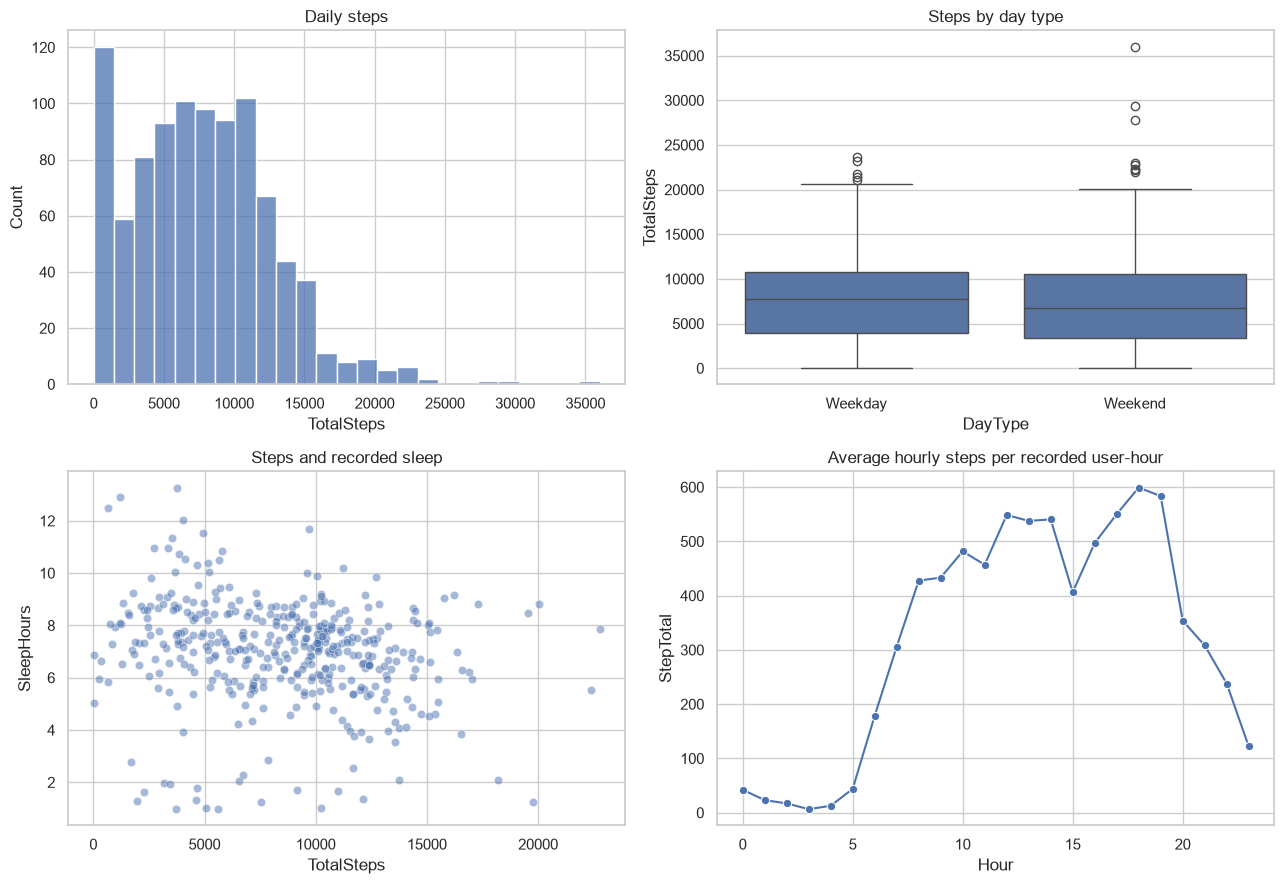

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(data=daily, x='TotalSteps', bins=25, ax=axes[0,0]); axes[0,0].set_title('Daily steps')
sns.boxplot(data=daily, x='DayType', y='TotalSteps', ax=axes[0,1]); axes[0,1].set_title('Steps by day type')
sns.scatterplot(data=daily.dropna(subset=['SleepHours']), x='TotalSteps', y='SleepHours', alpha=.5, ax=axes[1,0]); axes[1,0].set_title('Steps and recorded sleep')
hour_profile = hourly.groupby('Hour', as_index=False)['StepTotal'].mean()
sns.lineplot(data=hour_profile, x='Hour', y='StepTotal', marker='o', ax=axes[1,1]); axes[1,1].set_title('Average hourly steps per recorded user-hour')
plt.tight_layout(); plt.show()

## 8. Export
Run after all transformations. Use the daily and hourly tables separately in Power BI or SQL. Keep the original heart-rate CSV for second-level analysis.

In [24]:
daily.to_csv(OUTPUT_DIR / 'daily_wellness.csv', index=False)
hourly.to_csv(OUTPUT_DIR / 'hourly_activity.csv', index=False)
print('Saved', OUTPUT_DIR / 'daily_wellness.csv', 'shape', daily.shape)
print('Saved', OUTPUT_DIR / 'hourly_activity.csv', 'shape', hourly.shape)
print('Daily sleep coverage:', daily['SleepDataStatus'].value_counts().to_dict())
print('Hourly calorie matches:', hourly['CalorieMatch'].value_counts().to_dict())
print('Daily duplicate keys:', daily.duplicated(['Id','Date']).sum())
print('Hourly duplicate keys:', hourly.duplicated(['Id','ActivityHour']).sum())

Saved C:\Users\ankan\Desktop\LabmentixPR\Strava Fitness\Cleaned_Data\daily_wellness.csv shape (940, 54)
Saved C:\Users\ankan\Desktop\LabmentixPR\Strava Fitness\Cleaned_Data\hourly_activity.csv shape (22099, 11)
Daily sleep coverage: {'Unavailable': 530, 'Available': 410}
Hourly calorie matches: {'both': 22099, 'left_only': 0, 'right_only': 0}
Daily duplicate keys: 0
Hourly duplicate keys: 0


In [25]:
# One row per participant per day, with all six sources combined
output_file = OUTPUT_DIR / "fitness_all_six_daily.csv"

assert len(daily) == 940
assert not daily.duplicated(["Id", "Date"]).any()

daily.to_csv(output_file, index=False)

print(f"Saved: {output_file}")
print(f"Rows: {len(daily):,}")
print(f"Columns: {len(daily.columns)}")

Saved: C:\Users\ankan\Desktop\LabmentixPR\Strava Fitness\Cleaned_Data\fitness_all_six_daily.csv
Rows: 940
Columns: 54
